## Les bibliothéques utilisées

In [2]:

import matplotlib.pyplot as plt
import numpy as np


### Paramétres de choc

In [3]:
# Paramètres du choc
A = 0.2
x0 = 0.0
sigma = 1.0
D = 1.0
alpha = 0.1
L = 10
T = 5
Nx = 200

## Solution analytique(exact)

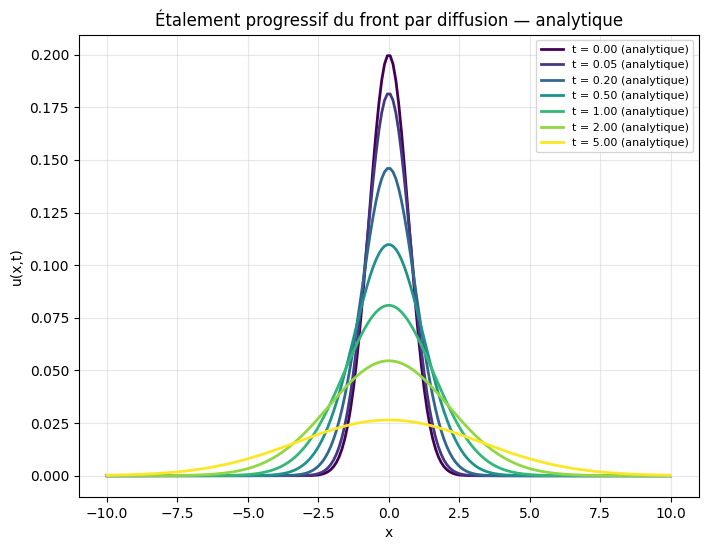

In [4]:

def u_analytique (x , t , A =0.2 , x0 =0.0 , sigma =1.0 , D =1.0 , alpha =0.1) :
#""" Solution analytique avec condition initiale gaussienne . """
  denom = np.sqrt (1 + (4* D * t / sigma **2))
  exp_part = np . exp ( -( x - x0 ) **2 / ( sigma **2 + 4* D * t ) )
  return A / denom * exp_part * np . exp ( - alpha * t )
# Paramètres
Nt = 100
x_Analytique = np . linspace ( -L , L , Nx )
t = np . linspace (0 , T , Nt )

# Calcul de la solution
U = np . zeros (( Nt , Nx ) )
# Précalcul de toute la matrice U (comme avant, mais sans plt dans la boucle)
for i, ti in enumerate(t):
    U[i, :] = u_analytique(x_Analytique, ti, A, x0, sigma, D, alpha)
    
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
    
temps_a_tracer = [1e-4, 0.05, 0.2, 0.5, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))

for k, (ti, c) in enumerate(zip(temps_a_tracer, colors)):
    # Solution analytique (couleur dégradée selon t)
    ax.plot(x_Analytique, u_analytique(x_Analytique, ti, A,x0, sigma, D, alpha),
            color=c, linewidth=2, label=f"t = {ti:.2f} (analytique)")

ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title("Étalement progressif du front par diffusion — analytique")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.savefig('diffusion_analytique.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
print(x_Analytique)

[-10.          -9.89949749  -9.79899497  -9.69849246  -9.59798995
  -9.49748744  -9.39698492  -9.29648241  -9.1959799   -9.09547739
  -8.99497487  -8.89447236  -8.79396985  -8.69346734  -8.59296482
  -8.49246231  -8.3919598   -8.29145729  -8.19095477  -8.09045226
  -7.98994975  -7.88944724  -7.78894472  -7.68844221  -7.5879397
  -7.48743719  -7.38693467  -7.28643216  -7.18592965  -7.08542714
  -6.98492462  -6.88442211  -6.7839196   -6.68341709  -6.58291457
  -6.48241206  -6.38190955  -6.28140704  -6.18090452  -6.08040201
  -5.9798995   -5.87939698  -5.77889447  -5.67839196  -5.57788945
  -5.47738693  -5.37688442  -5.27638191  -5.1758794   -5.07537688
  -4.97487437  -4.87437186  -4.77386935  -4.67336683  -4.57286432
  -4.47236181  -4.3718593   -4.27135678  -4.17085427  -4.07035176
  -3.96984925  -3.86934673  -3.76884422  -3.66834171  -3.5678392
  -3.46733668  -3.36683417  -3.26633166  -3.16582915  -3.06532663
  -2.96482412  -2.86432161  -2.7638191   -2.66331658  -2.56281407
  -2.4623115

## Solution volumes finis

espace de temps 0.004500000000000001 espace de position 0.1


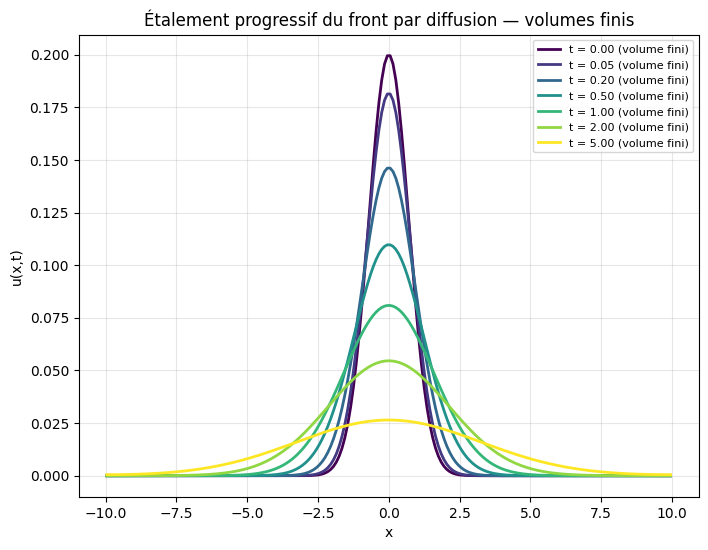

In [6]:

# Paramètres

dx = 2*L / Nx
x_VF = -L + (np.arange(Nx) + 0.5) * dx 
clf = 0.45
dt = clf * dx **2 / D
Nt = int(T / dt) + 1 

print("espace de temps",dt,"espace de position",dx)
U_num = np.zeros((Nt, Nx))
t_VF = np.linspace(0, T, Nt)
U_num[0, :] = A * np.exp(-(x_VF - x0)**2 / sigma**2) 
r = D * dt / dx ** 2
def u_volume_finie():
    for i in range(Nt-1):
        for j in range(1, Nx-1):
            U_num[i+1,j] = U_num[i,j] + r*(U_num[i,j+1] - 2*U_num[i,j] + U_num[i,j-1]) - alpha*dt*U_num[i,j]
        U_num[i+1, 0]  = U_num[i+1, 1]
        U_num[i+1, -1] = U_num[i+1, -2]
u_volume_finie()

plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
    
temps_a_tracer = [1e-4, 0.05, 0.2, 0.5, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))

for k, (ti, c) in enumerate(zip(temps_a_tracer, colors)):
    

    # Solution numérique (volumes finis) : étoiles rouges
    idx = np.argmin(np.abs(t_VF - ti))
    ax.plot(x_VF, U_num[idx, :], linewidth=2, label=f"t = {ti:.2f} (volume fini)", color=c, )

ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title("Étalement progressif du front par diffusion — volumes finis")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.savefig('diffusion_VF.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
print(x_VF)

[-9.95 -9.85 -9.75 -9.65 -9.55 -9.45 -9.35 -9.25 -9.15 -9.05 -8.95 -8.85
 -8.75 -8.65 -8.55 -8.45 -8.35 -8.25 -8.15 -8.05 -7.95 -7.85 -7.75 -7.65
 -7.55 -7.45 -7.35 -7.25 -7.15 -7.05 -6.95 -6.85 -6.75 -6.65 -6.55 -6.45
 -6.35 -6.25 -6.15 -6.05 -5.95 -5.85 -5.75 -5.65 -5.55 -5.45 -5.35 -5.25
 -5.15 -5.05 -4.95 -4.85 -4.75 -4.65 -4.55 -4.45 -4.35 -4.25 -4.15 -4.05
 -3.95 -3.85 -3.75 -3.65 -3.55 -3.45 -3.35 -3.25 -3.15 -3.05 -2.95 -2.85
 -2.75 -2.65 -2.55 -2.45 -2.35 -2.25 -2.15 -2.05 -1.95 -1.85 -1.75 -1.65
 -1.55 -1.45 -1.35 -1.25 -1.15 -1.05 -0.95 -0.85 -0.75 -0.65 -0.55 -0.45
 -0.35 -0.25 -0.15 -0.05  0.05  0.15  0.25  0.35  0.45  0.55  0.65  0.75
  0.85  0.95  1.05  1.15  1.25  1.35  1.45  1.55  1.65  1.75  1.85  1.95
  2.05  2.15  2.25  2.35  2.45  2.55  2.65  2.75  2.85  2.95  3.05  3.15
  3.25  3.35  3.45  3.55  3.65  3.75  3.85  3.95  4.05  4.15  4.25  4.35
  4.45  4.55  4.65  4.75  4.85  4.95  5.05  5.15  5.25  5.35  5.45  5.55
  5.65  5.75  5.85  5.95  6.05  6.15  6.25  6.35  6

### la visualisation des deux solutions

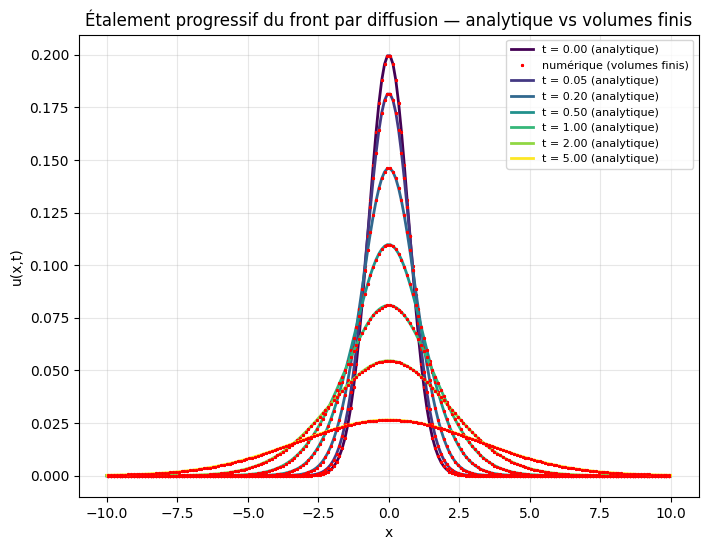

In [8]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
    
temps_a_tracer = [1e-4, 0.05, 0.2, 0.5, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))

for k, (ti, c) in enumerate(zip(temps_a_tracer, colors)):
    # Solution analytique (couleur dégradée selon t)
    ax.plot(x_Analytique, u_analytique(x_Analytique, ti, A,x0, sigma, D, alpha),
            color=c, linewidth=2, label=f"t = {ti:.2f} (analytique)")

    # Solution numérique (volumes finis) : étoiles rouges
    idx = np.argmin(np.abs(t_VF - ti))
    ax.plot(x_VF, U_num[idx, :], color="red", marker='*', markersize=2,
             linestyle='none',
            label="numérique (volumes finis)" if k == 0 else None)

ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title("Étalement progressif du front par diffusion — analytique vs volumes finis")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.savefig('diffusion_analytique_vs_VF.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
def u_analytique_bornee(x, t, A=A, x0=x0, sigma=sigma, D=D, alpha=alpha, L=L, N_images=6):
    """Solution exacte sur domaine borné avec Neumann, par méthode des images."""
    u = np.zeros_like(x)
    for n in range(-N_images, N_images + 1):
        # image "directe" décalée d'une période 4L
        u += u_analytique(x, t, A, x0 + 4*n*L, sigma, D, alpha)
        # image "réfléchie"
        u += u_analytique(x, t, A, -x0 + 4*n*L, sigma, D, alpha)
    return u

### l'erreur 

In [10]:
import numpy as np

def erreurs_L2_Linf(x, U_numn, U_exact, dx):
    """
    Calcule les erreurs L2 et L_infini entre solution numérique et exacte.
    U_num, U_exact : tableaux 1D de même taille (valeurs de u sur x)
    """
    diff = U_numn - U_exact
    L2 = np.sqrt(dx * np.sum(diff**2))
    Linf = np.max(np.abs(diff))
    return L2, Linf



In [11]:
print(U)

[[7.44015195e-45 5.49729237e-44 3.98054430e-43 ... 3.98054430e-43
  5.49729237e-44 7.44015195e-45]
 [1.34431003e-37 7.09722897e-37 3.68450637e-36 ... 3.68450637e-36
  7.09722897e-37 1.34431003e-37]
 [1.95518619e-32 8.12470882e-32 3.32796542e-31 ... 3.32796542e-31
  8.12470882e-32 1.95518619e-32]
 ...
 [2.10251611e-04 2.31692007e-04 2.55068480e-04 ... 2.55068480e-04
  2.31692007e-04 2.10251611e-04]
 [2.18227025e-04 2.40253996e-04 2.64247487e-04 ... 2.64247487e-04
  2.40253996e-04 2.18227025e-04]
 [2.26310209e-04 2.48922687e-04 2.73531303e-04 ... 2.73531303e-04
  2.48922687e-04 2.26310209e-04]]


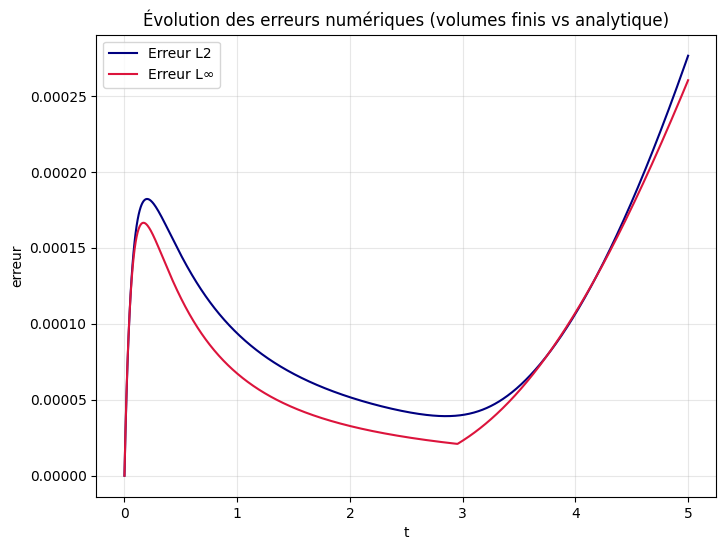

Erreur L2 max sur toute la simulation   : 0.000277
Erreur L∞ max sur toute la simulation   : 0.000260


In [12]:
L2_list = []
Linf_list = []

for n in range(Nt):
    U_exacte_n = u_analytique(x_VF, t_VF[n], A, x0, sigma, D, alpha)
    U_num_n = U_num[n, :]
    L2_n, Linf_n = erreurs_L2_Linf(x_VF, U_num_n, U_exacte_n, dx)
    L2_list.append(L2_n)
    Linf_list.append(Linf_n)

L2_list = np.array(L2_list)
Linf_list = np.array(Linf_list)

# --- Graphe de l'évolution des erreurs ---
plt.figure(figsize=(8, 6))
plt.plot(t_VF, L2_list, label="Erreur L2", color='navy')
plt.plot(t_VF, Linf_list, label="Erreur L∞", color='crimson')
plt.xlabel('t')
plt.ylabel('erreur')
plt.title("Évolution des erreurs numériques (volumes finis vs analytique)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('erreurs_numeriques.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Erreur L2 max sur toute la simulation   : {L2_list.max():.6f}")
print(f"Erreur L∞ max sur toute la simulation   : {Linf_list.max():.6f}")

In [13]:
scenarios = {
    "Diffusion pure (alpha=0)":       dict(D=1.0, alpha=0.0,  sigma=1.0, clf=0.45),
    "Décroissance dominante":         dict(D=0.2, alpha=1.0,  sigma=1.0, clf=0.45),
    "Diffusion rapide":               dict(D=5.0, alpha=0.1,  sigma=1.0, clf=0.45),
    "Front raide":                    dict(D=1.0, alpha=0.1,  sigma=0.3, clf=0.45),
    "Front large":                    dict(D=1.0, alpha=0.1,  sigma=3.0, clf=0.45),
    "Diffusion lente":                dict(D=0.05, alpha=0.1, sigma=1.0, clf=0.45),
    "Décroissance nulle + rapide":    dict(D=5.0, alpha=0.0,  sigma=1.0, clf=0.45),
    "Décroissance forte + lente":     dict(D=0.05, alpha=1.0, sigma=1.0, clf=0.45),
    "CFL limite (0.5)":               dict(D=1.0, alpha=0.1,  sigma=1.0, clf=0.5),
    "Instable (CFL > 0.5)":           dict(D=1.0, alpha=0.1,  sigma=1.0, clf=0.6),
}

resultats = {}

for nom, p in scenarios.items():
    # On réassigne les globales utilisées par u_volume_finie()
    D, alpha, sigma, clf = p["D"], p["alpha"], p["sigma"], p["clf"]

    dx = 2 * L / Nx
    x_VF = -L + (np.arange(Nx) + 0.5) * dx
    dt = clf * dx**2 / D
    Nt = int(T / dt) + 1
    t = np.linspace(0, T, Nt)

    U = np.zeros((Nt, Nx))
    U[0, :] = A * np.exp(-(x_VF - x0)**2 / sigma**2)
    r = D * dt / dx**2

    for i in range(Nt - 1):
        U[i, 0] = U[i, 1]
        U[i, -1] = U[i, -2]

        U[i + 1, 1:-1] = (
            U[i, 1:-1]
            + r * (U[i, 2:] - 2 * U[i, 1:-1] + U[i, :-2])
            - alpha * dt * U[i, 1:-1]
        )

        U[i + 1, 0] = U[i + 1, 1]
        U[i + 1, -1] = U[i + 1, -2]

    # --- NOUVEAU : on calcule la solution exacte avec les MÊMES D, alpha, sigma ---
    U_exacte = np.zeros((Nt, Nx))
    for i, ti in enumerate(t):
        U_exacte[i, :] = u_analytique(x_VF, ti, A=A, x0=x0, sigma=sigma, D=D, alpha=alpha)

    resultats[nom] = dict(x=x_VF.copy(), t=t.copy(), U=U.copy(), U_exacte=U_exacte,
                           dx=dx, D=D, alpha=alpha, sigma=sigma, clf=clf, dt=dt, r=r)

## Comparaison analytique vs volumes finis — tous les scénarios

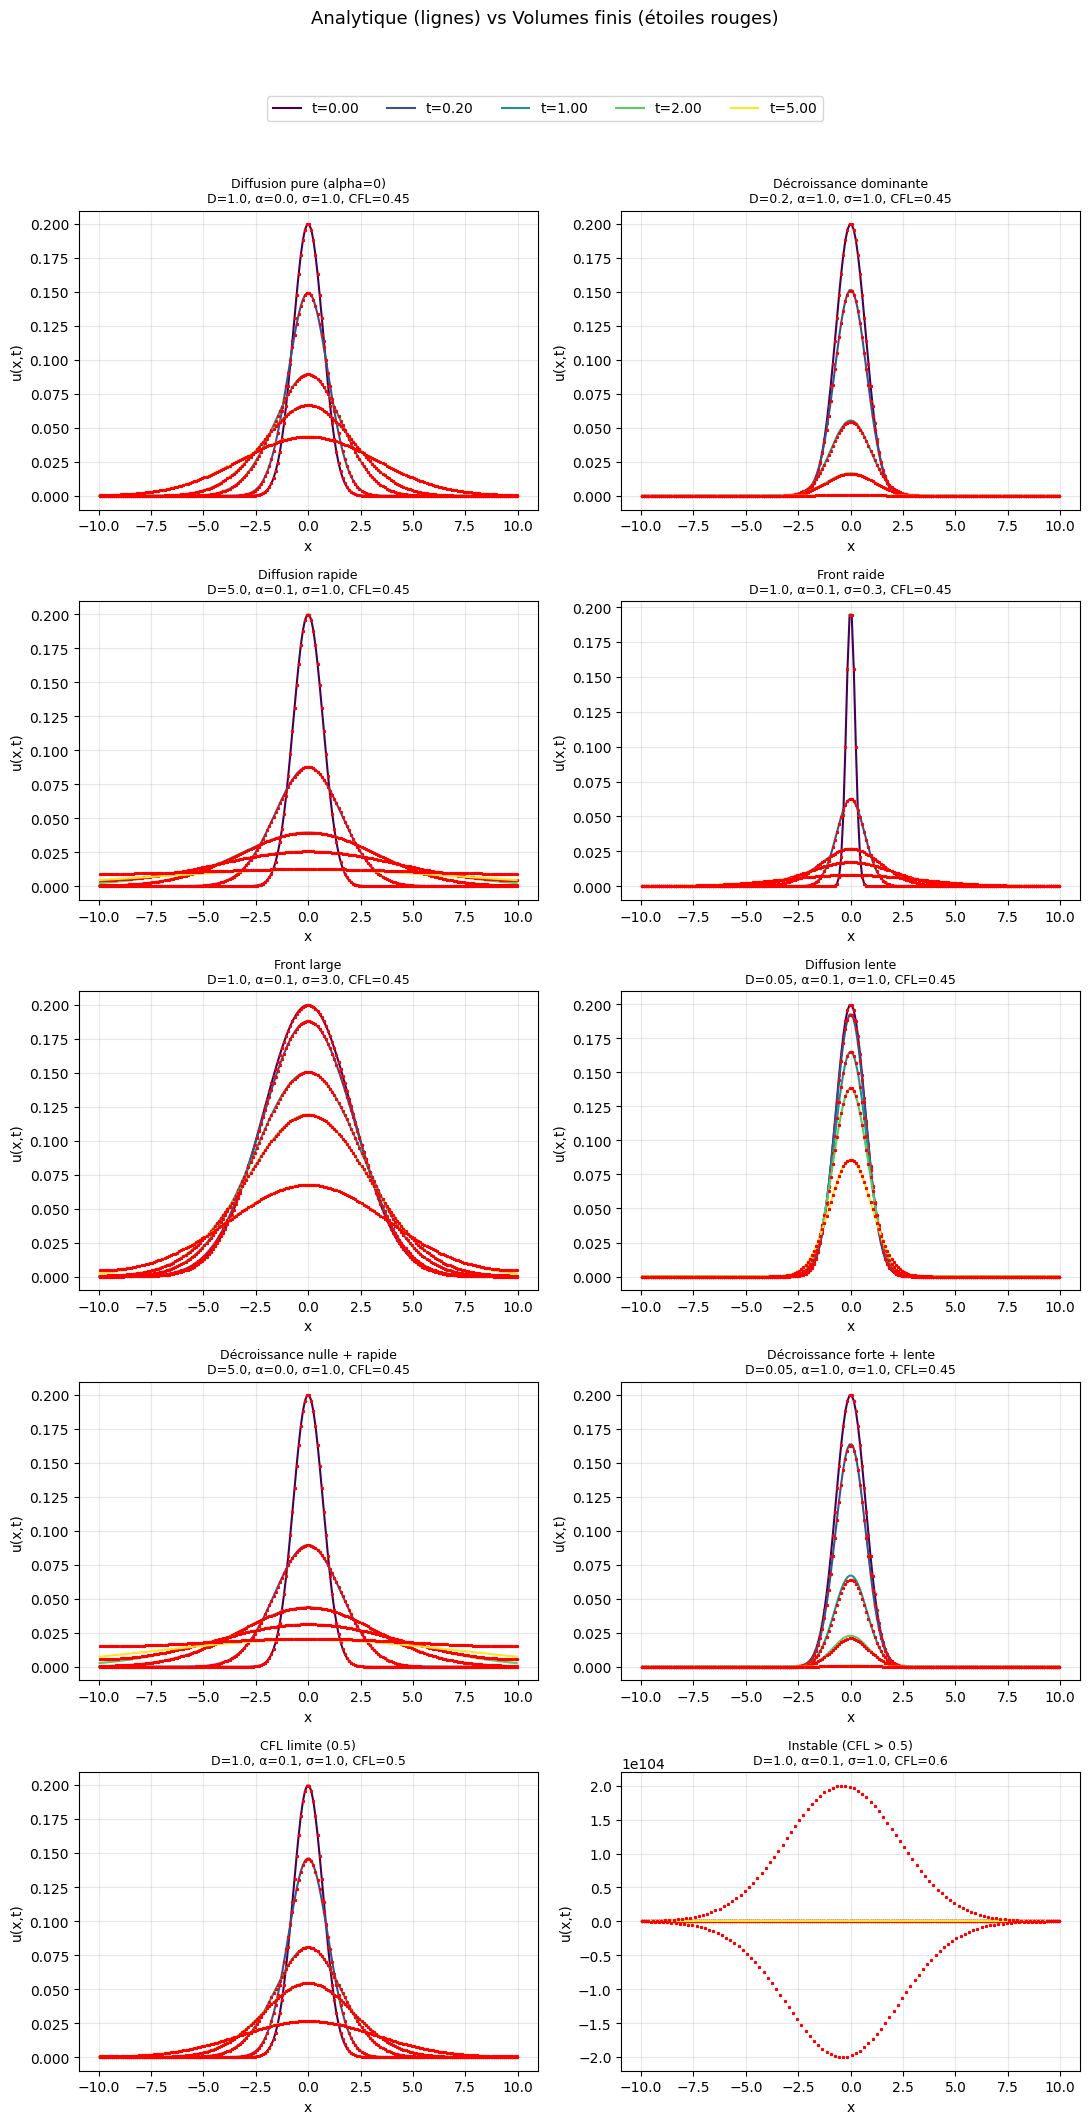

In [ ]:
import math

noms = list(resultats.keys())
n_scen = len(noms)
ncols = 2
nrows = math.ceil(n_scen / ncols)

plt.style.use('default')
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

temps_a_tracer = [1e-4, 0.2, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))

for k, nom in enumerate(noms):
    ax = axes[k]
    res = resultats[nom]
    x_r, t_r, U_r = res["x"], res["t"], res["U"]
    D_r, alpha_r, sigma_r = res["D"], res["alpha"], res["sigma"]

    for ti, c in zip(temps_a_tracer, colors):
        idx = np.argmin(np.abs(t_r - ti)) 
        U_exacte = res["U_exacte"] 
        ax.plot(x_r, U_exacte[idx], color=c, linewidth=1.5, label=f"t={ti:.2f}")

        idx = np.argmin(np.abs(t_r - ti))
        ax.plot(x_r, U_r[idx, :], color="red", marker='*', markersize=2,
                linestyle='none')

    ax.set_title(f"{nom}\nD={D_r}, α={alpha_r}, σ={sigma_r}, CFL={res['clf']}", fontsize=9)
    ax.set_xlabel('x')
    ax.set_ylabel('u(x,t)')
    ax.grid(True, alpha=0.3)

# Cacher les axes vides s'il y en a
for k in range(n_scen, len(axes)):
    axes[k].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(temps_a_tracer), bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Analytique (lignes) vs Volumes finis (étoiles rouges)", y=1.06, fontsize=13)
plt.tight_layout()
plt.savefig('diffusion_scenarios.png', dpi=300, bbox_inches='tight')
plt.show()


## Tableau récapitulatif de tous les scénarios

In [ ]:
print(f"{'Scénario':30s} {'D':>6s} {'alpha':>7s} {'sigma':>7s} {'CFL':>6s} {'Nt':>7s} {'L2_max':>12s} {'Linf_max':>12s}")
print("-" * 100)
for nom in noms:
    res = resultats[nom]
    err = erreurs_max[nom]
    print(f"{nom:30s} {res['D']:6.2f} {res['alpha']:7.2f} {res['sigma']:7.2f} "
          f"{res['clf']:6.2f} {len(res['t']):7d} {err['L2_max']:12.4e} {err['Linf_max']:12.4e}")


Scénario                            D   alpha   sigma    CFL      Nt       L2_max     Linf_max
----------------------------------------------------------------------------------------------------


NameError: name 'erreurs_max' is not defined

### Génération de dataset à partir de solution exacte